In [1]:
import pandas as pd
import numpy as np

# Load the dataset
# Ensure the 'AB_NYC_2019.csv' file is in the same folder as this script
df = pd.read_csv('AB_NYC_2019.csv')



# 1. Handling Missing Values
# Fill missing 'name' and 'host_name' with 'Unknown'
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

# Fill missing 'reviews_per_month' with 0 (No reviews means 0 reviews/month)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Drop 'last_review' as it has many missing values and isn't needed for numeric EDA
df.drop(['last_review'], axis=1, inplace=True)

# 2. Correcting Inconsistent/Dirty Data
# In New York City data, price 0 is likely an error. 
# We replace it with the median price as a best practice for dirty data.
median_price = df['price'].median()
df.loc[df['price'] <= 0, 'price'] = median_price

# 3. Standardizing Categories
# Clean room_type and neighborhood_group to be lowercase and without extra spaces
df['room_type'] = df['room_type'].str.strip().str.lower()
df['neighbourhood_group'] = df['neighbourhood_group'].str.strip().str.lower()

# 4. Final Summary Check
print("Cleaning Complete. Missing values:")
print(df.isnull().sum())

# Save the result to a new file for the project
df.to_csv('Cleaned_AB_NYC_2019.csv', index=False)
print("\nCleaned file saved as 'Cleaned_AB_NYC_2019.csv'")

Cleaning Complete. Missing values:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Cleaned file saved as 'Cleaned_AB_NYC_2019.csv'


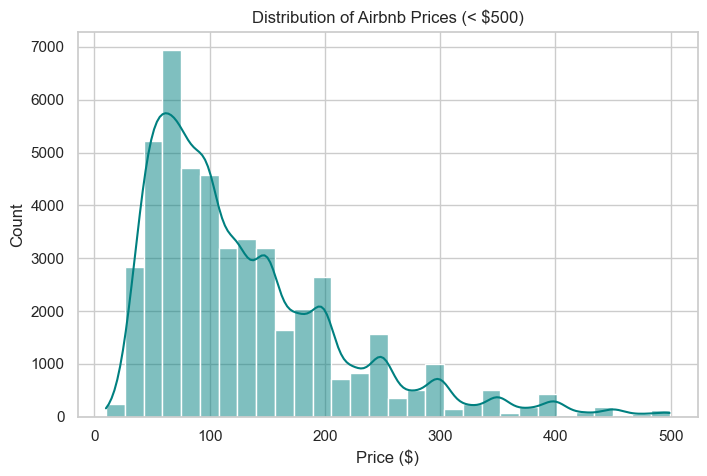

C:\Users\zicoo\AppData\Local\Temp\ipykernel_16004\3091507658.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='neighbourhood_group', palette='magma')


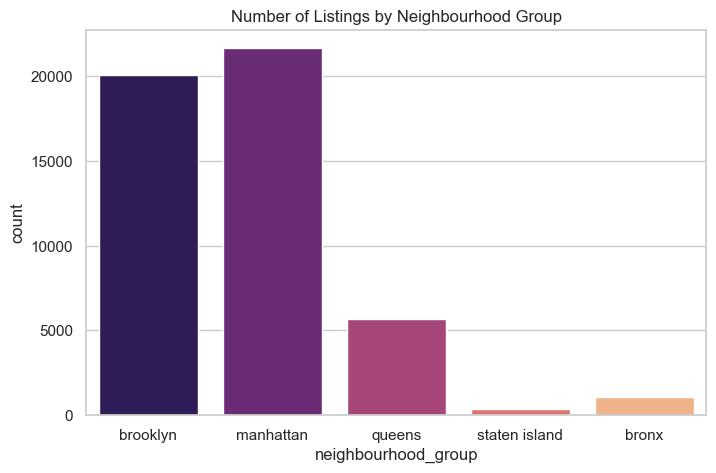

C:\Users\zicoo\AppData\Local\Temp\ipykernel_16004\3091507658.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['price'] < 500], x='room_type', y='price', palette='Set2')


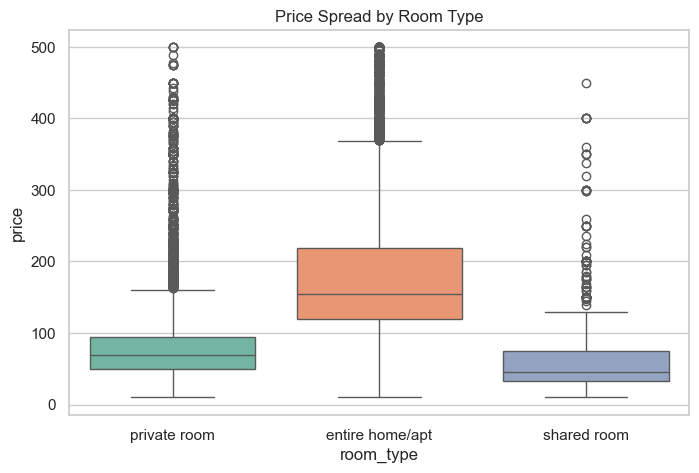

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv('Cleaned_AB_NYC_2019.csv')
sns.set_theme(style="whitegrid")

# --- CHART 1: Histogram (Price Distribution) ---
plt.figure(figsize=(8, 5))
sns.histplot(df[df['price'] < 500]['price'], bins=30, kde=True, color='teal')
plt.title('Distribution of Airbnb Prices (< $500)')
plt.xlabel('Price ($)')
plt.show()

# --- CHART 2: Countplot (Listings per Borough) ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='neighbourhood_group', palette='magma')
plt.title('Number of Listings by Neighbourhood Group')
plt.show()

# --- CHART 3: Boxplot (Price vs Room Type) ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['price'] < 500], x='room_type', y='price', palette='Set2')
plt.title('Price Spread by Room Type')
plt.show()

In [4]:
# Statistical Insights for your report
print("--- PROJECT INSIGHTS ---")

# Insight for Chart 2
print("\nListings Count per Borough:")
print(df['neighbourhood_group'].value_counts())

# Insight for Chart 3
print("\nAverage Price per Room Type:")
print(df.groupby('room_type')['price'].mean())

# Insight for Outliers
print(f"\nMaximum Price found in data: ${df['price'].max()}")

--- PROJECT INSIGHTS ---

Listings Count per Borough:
neighbourhood_group
manhattan        21661
brooklyn         20104
queens            5666
bronx             1091
staten island      373
Name: count, dtype: int64

Average Price per Room Type:
room_type
entire home/apt    211.802590
private room        89.814208
shared room         70.310345
Name: price, dtype: float64

Maximum Price found in data: $10000
